# Lecture 12: Convolutional Neural Networks

How to "read" this lecture notebook
<details>
<summary>click to expand</summary>

As you go through this notebook (or any notebook for this class), you will encounter new concepts and Python code that implements them, just like you would see in a textbook. In a textbook, it's easy to read code and an explanation of what it does and think that you understand it.
<br />

### Learn by doing
This notebook is different from a textbook because it allows you to not just read the code, but play with it. **You can and should try changing the code that you see**. In many places throughout this reading notebook, you will be asked to write your own code to experiment with a concept that was just covered. This is a form of "active reading" and the idea behind it is that we really learn by **doing**.
<br />

### Change everything
Don't feel limited to only changing code when prompted. This notebook is your learning environment and your playground. Try changing and running code throughout the notebook and even **add your own notes and new code blocks**. Adding comments to code to explain what you are testing, experimenting with, or trying to do is helpful when you revisit it later.
<br />

### Make this notebook your own
Make this notebook your own. Write your questions and thoughts. At the end of every reading notebook, you will be asked the same set of questions to elicit your questions, reactions, and feedback. When we review the reading notebook in class, I encourage you to share!

</details>

## Learning Objectives

By the end of this lecture, you will be able to:
- Explain how convolutional operations work and why they outperform MLPs on image data
- Use PyTorch's `nn.Conv2d` and pooling layers to build convolutional networks
- Calculate output dimensions at each stage of a CNN
- Build and train a CNN to classify handwritten digits with >99% accuracy on MNIST
- Design a deeper CNN for more complex image classification (CIFAR-10)
- Apply data augmentation to improve generalization

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 10px 0px 0;
  ">
    👁️
  </span>

  CNNs are arguably one of the most impactful architectures in the history of deep learning. The same ideas that power digit recognition power self-driving cars, medical diagnosis, and face recognition. **By the end of this lecture, you'll understand exactly how they work — and you'll have built one from scratch.**
  <div style="clear: both;"></div>
</div>

# 12.0 Code Preface

In [1]:
# Core imports for this lecture
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


# 12.1 Convolutional Layers

<img alt="Terminator vision" src="../images/L12_terminator_vision.gif" width=900 style="display:block;">
<font size=2>The T-800's visual processor scans the scene, using convolutional filters to detect edges, textures, and shapes in <i>Terminator 2: Judgment Day (1991)</i></font>

So far, when working with neural networks, we've fed images in as **flat vectors** — taking a 28×28 image and stretching it into a single list of 784 numbers. This works, but it throws away something crucial: **spatial structure**. The pixel at position (10, 10) is much more related to the pixel at (10, 11) than to the one at (1, 27). An MLP has no way to know this *a priori* (though presumably it can learn it with enough data).

**Convolutional Neural Networks (CNNs)** are designed to exploit spatial structure. Instead of learning a separate weight for every pixel, CNNs use small **filters** (also called **kernels**) that slide across the image and look for the same pattern everywhere. This gives CNNs two powerful properties:

- **Parameter sharing**: The same filter is reused at every position, dramatically reducing the number of parameters
- **Translation invariance**: A feature detector (like "edge detector") works whether the edge appears in the top-left or bottom-right of the image

This is why CNNs dominated image recognition benchmarks starting in 2012 (AlexNet) and why they remain the a go-to architecture for image data today.

## What is a Convolution?

<img alt="A 3x3 kernel sliding across a 6x6 image, producing a 4x4 output feature map" src="../images/L12_convolution.gif" width=900 style="display:block;">
<font size=2>A convolution kernel slides across the input (image), computing a weighted sum of the pixels as a value in the output (feature map).</font>

A convolution is a simple sliding window operation:

1. Place a small matrix (the **kernel** or **filter**) at the top-left of the image
2. Multiply each kernel value by the corresponding pixel
3. Sum all the products — this produces **one output value**
4. Slide the kernel one position to the right and repeat
5. After covering the entire row, move down one row and repeat

The result is an **output feature map** that represents how strongly each position in the image matches the pattern the kernel describes.

In the animated example above, the filter <font color="blue">detects a horizontal edge</font>, which you understand by looking at the kernal values: positive weights on the top row, negative weights on the bottom row, and zeros in the middle. When this kernel is placed over a horizontal edge (light pixels above dark pixels), the positive and negative contributions add up to a large value, indicating a strong match.

Let's implement this manually to make it concrete:

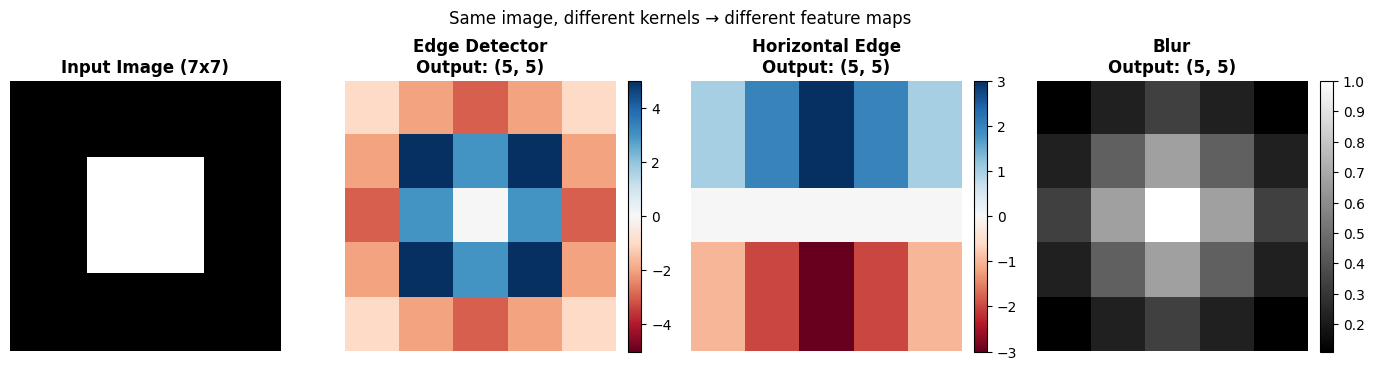

In [2]:
# Manual convolution — implementing it in NumPy to see what really happens

# A simple 7x7 'image' — think of it as grayscale pixel values
image = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# Three different 3x3 kernels — each detects a different pattern
kernels = {
    'Edge Detector': np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=float),
    'Horizontal Edge': np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=float),
    'Blur': np.ones((3, 3), dtype=float) / 9.0,   # Average of neighborhood
}

def apply_convolution(image, kernel):
    """Apply a convolution kernel to an image (no padding = 'valid' mode)."""
    h_out = image.shape[0] - kernel.shape[0] + 1
    w_out = image.shape[1] - kernel.shape[1] + 1
    output = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            patch = image[i:i+3, j:j+3]            # The current window
            output[i, j] = np.sum(patch * kernel)  # Weighted sum
    return output

# Colormap choices: RdBu (diverging) for edge kernels that produce negatives;
# gray for blur which only produces positive averages.
kernel_cmaps = {
    'Edge Detector':   'RdBu',
    'Horizontal Edge': 'RdBu',
    'Blur':            'gray',
}

# Visualize: image and three output feature maps
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Input Image (7x7)', fontweight='bold')
axes[0].axis('off')

for ax, (name, kernel) in zip(axes[1:], kernels.items()):
    out = apply_convolution(image, kernel)
    cmap = kernel_cmaps[name]
    # Symmetric limits for diverging maps so zero stays at white;
    # auto-scale for gray (blur) so the full range is visible.
    if cmap == 'RdBu':
        abs_max = np.abs(out).max()
        vmin, vmax = -abs_max, abs_max
    else:
        vmin, vmax = out.min(), out.max()
    im = ax.imshow(out, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'{name}\nOutput: {out.shape}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Same image, different kernels → different feature maps', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

We can see that the output feature map has smaller dimensions than the input image. In general, <font color="blue">convolutions change the shape of tensors</font> that pass through them:

In [3]:
# Our input image of shape (7, 7) convolved with a (3, 3) kernel produces an output feature map of shape (5, 5) 
print(f"Input shape:  {image.shape}")
print(f"Kernel shape: (3, 3)")
print(f"Output shape: {apply_convolution(image, kernels['Edge Detector']).shape}")

Input shape:  (7, 7)
Kernel shape: (3, 3)
Output shape: (5, 5)


The size of the output depends on the kernel size and the stride (how much we slide the kernel each time). We'll learn a formula for exactly how to calculate output dimensions in a moment. For now, the key takeaway is that **convolutions transform the input image into a new representation (the feature map) that highlights certain patterns**.

Here's an example of different kernels applied to a real image:

<img alt="Output feature maps for different kernels on a real image" src="../images/L12_house_filters.gif" width=800 style="display:block;">


Notice that the same input image produces completely different feature maps depending on the kernel. But, unlike in digital processing engineering, where we might create certain filters for our use case, <font color="blue">a neural net doesn't need to be told which filters to use, it **learns** them from data</font>.

Early layers typically learn low-level features (edges, corners, textures). Deeper layers combine these to detect higher-level features (shapes, objects). This **hierarchical feature learning** is the core insight behind why CNNs work so well.

## `nn.Conv2d` in PyTorch

PyTorch's `nn.Conv2d` applies multiple learnable filters to a 2D input. Its key parameters are:

| Parameter | Meaning |
|-----------|----------|
| `in_channels` | Number of input channels (1 for grayscale, 3 for RGB) |
| `out_channels` | Number of filters to learn (= number of output feature maps) |
| `kernel_size` | Filter width/height (e.g., `3` means 3×3 filters) |
| `stride` | Step size when sliding the filter (default: 1) |
| `padding` | Pixels added around the border (0 = 'valid', 1 = keeps size with 3×3 kernel) |

PyTorch tensors for image data follow the convention: **(batch, channels, height, width)** — often written as `(N, C, H, W)`.

Let's start with a batch of 28x28 images (like MNIST) and see how `nn.Conv2d` transforms them:

In [4]:
# Understanding Conv2d shapes

# Batch of 4 grayscale 28x28 images (like MNIST)
x = torch.randn(4, 1, 28, 28)  # (N=4, C=1, H=28, W=28)

# Apply 32 filters of size 3x3 with padding=1 to preserve spatial dimensions
conv = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
out = conv(x)

In [5]:
print("=== Shapes ===")
print(f"Input:   {tuple(x.shape)}   (batch, in_channels, height, width)")
print(f"Output:  {tuple(out.shape)}  (batch, out_channels, height, width)")

=== Shapes ===
Input:   (4, 1, 28, 28)   (batch, in_channels, height, width)
Output:  (4, 32, 28, 28)  (batch, out_channels, height, width)


How many parameters does our `Conv2d` layer have to learn?

In [6]:
print("=== Learned Parameters ===")
print(f"Filters (weight): {tuple(conv.weight.shape)}  (out_channels, in_channels, k_h, k_w)")
print(f"Bias:             {tuple(conv.bias.shape)}")
print(f"Total parameters: {sum(p.numel() for p in conv.parameters()):,}")

=== Learned Parameters ===
Filters (weight): (32, 1, 3, 3)  (out_channels, in_channels, k_h, k_w)
Bias:             (32,)
Total parameters: 320


By comparison, suppose we had a fully connected layer instead of `Conv2d`, how many parameters would that have to learn?

In [7]:
# For comparison: what would a fully-connected layer need for the same input?
n_pixels = 1 * 28 * 28   # 784 input pixels
n_outputs = 32 * 28 * 28  # 32 feature maps × 28×28 spatial
fc_params = n_pixels * n_outputs + n_outputs  # weights + biases
print(f"A fully connected layer would need: {fc_params:,} parameters!")

# Or as a ratio:
print(f"In other words, {fc_params / sum(p.numel() for p in conv.parameters()):,.0f} TIMES more parameters!")

A fully connected layer would need: 19,694,080 parameters!
In other words, 61,544 TIMES more parameters!


This is why convolution is so powerful, we save a ton in parameters but we also gain by **<font color="blue">asserting translational invariance!</font>** The network learns the same filter that is applied across all regions of the entire image.

## Stride and Padding

**Padding** (adding blank pixels around the image) affects the output size:
- `padding=0 or padding='valid'`: no padding, output is smaller than input ('valid' is a term from the Digital Signal Processing days)
- `padding=1` with `kernel_size=3`: adds one pixel of zeros around the border, **output size = input size**
- `padding='same'`: PyTorch calculates the exact padding needed to preserve spatial dimensions

**Stride** controls how far the kernel moves at each step:
- `stride=1`: move one pixel at a time (most common)
- `stride=2`: skip every other position — this **halves** the spatial dimensions


Here's an example of a convolution with a stride of 2:

<img alt="Convolution with a stride of 2" src="../images/L12_convolution_stride2.gif" width=800>

You can specify different padding and stride values for each dimension (height and width), if needed, but PyTorch assumes the same values for both dimensions unless specified otherwise.

The general formule for **each output dimension** of a convolution with padding and stride in that dimension is:

$$H_{out} = \left\lfloor \frac{H_{in} + 2 \times padding - kernel\_size}{stride} \right\rfloor + 1$$

This formula is essential for designing CNN architectures — you need to track tensor shapes layer by layer.

Let's see some examples of how different values of padding and stride affect the shape:

In [8]:
# Demonstrating how stride and padding affect output size

x = torch.randn(1, 1, 28, 28)  # Single 28x28 image

configs = [
    dict(kernel_size=3, stride=1, padding=0),  # 'valid' — shrinks output
    dict(kernel_size=3, stride=1, padding=1),  # Same padding — preserves size
    dict(kernel_size=3, stride=2, padding=1),  # Stride 2 — halves size
    dict(kernel_size=5, stride=1, padding=2),  # 5x5 kernel, same padding
    dict(kernel_size=5, stride=2, padding=0),  # 5x5, stride 2, no pad
]

print(f"input shape: {str(tuple(x.shape)):>10}")
print()
print(f"{'kernel':<8} {'stride':>8} {'padding':>10} {'output shape':>15}")
print("-" * 50)
for cfg in configs:
    conv = nn.Conv2d(1, 1, **cfg)
    out = conv(x)
    k = cfg['kernel_size']
    print(f"{k}x{k}:  {cfg['stride']:>8}   {cfg['padding']:>8}   {str(tuple(out.shape)):>17}")

input shape: (1, 1, 28, 28)

kernel     stride    padding    output shape
--------------------------------------------------
3x3:         1          0      (1, 1, 26, 26)
3x3:         1          1      (1, 1, 28, 28)
3x3:         2          1      (1, 1, 14, 14)
5x5:         1          2      (1, 1, 28, 28)
5x5:         2          0      (1, 1, 12, 12)


## Feature Maps and Multiple Channels

Each `out_channels` value in `nn.Conv2d` produces one **feature map** — a 2D grid showing where the input activates that particular filter. More filters = more diverse features the layer can detect.

When the input has multiple channels (e.g., RGB has 3 channels), each filter has a depth matching the input channels. A `Conv2d(3, 32, 3)` layer learns 32 filters of shape (3, 3, 3) — each filter combines information from all 3 RGB channels into a single output feature map.

In [9]:
# Channels: tracing through multi-channel convolutions

# RGB image: 3 input channels
rgb_image = torch.randn(1, 3, 32, 32)   # (batch=1, C=3, H=32, W=32)

# First conv: 3 channels -> 32 feature maps
conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
feat1 = conv1(rgb_image)

# Second conv: 32 channels -> 64 feature maps
conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
feat2 = conv2(feat1)

print("Channel flow through stacked convolutions:")
print(f"  Input:  {tuple(rgb_image.shape)}  — RGB image")
print(f"  Conv1:  {tuple(feat1.shape)}  — 32 feature maps")
print(f"  Conv2:  {tuple(feat2.shape)}  — 64 feature maps")
print()
print("Filter shapes (weight tensors):")
print(f"  conv1.weight: {tuple(conv1.weight.shape)}  (out, in, kH, kW) = 32 filters × 3 channels × 3×3")
print(f"  conv2.weight: {tuple(conv2.weight.shape)} (out, in, kH, kW) = 64 filters × 32 channels × 3×3")

Channel flow through stacked convolutions:
  Input:  (1, 3, 32, 32)  — RGB image
  Conv1:  (1, 32, 32, 32)  — 32 feature maps
  Conv2:  (1, 64, 32, 32)  — 64 feature maps

Filter shapes (weight tensors):
  conv1.weight: (32, 3, 3, 3)  (out, in, kH, kW) = 32 filters × 3 channels × 3×3
  conv2.weight: (64, 32, 3, 3) (out, in, kH, kW) = 64 filters × 32 channels × 3×3


You can think of the combination of filters across channels as learning to detect more complex patterns that involve multiple colors or textures. For example, one filter might learn to detect a red edge, while another learns to detect a blue corner, and together they can identify more complex shapes in the image.

# 12.2 Pooling and CNN Architecture

After convolution, we typically reduce the spatial dimensions using **pooling**.

Pooling:
- Reduces the size of feature maps, lowering computation in later layers
- Provides a degree of **spatial invariance** — the exact position of a feature matters less
- Helps the network focus on whether a feature is present rather than exactly where it is

**MaxPooling** takes the maximum value in each window — it asks "is this feature present anywhere in this region?"

<img alt="Max pooling" src="../images/L12_max_pooling.png" width=600>

<br />
<br />

**AveragePooling** takes the average — it asks "how strongly is this feature present on average?"

<img alt="Average pooling" src="../images/L12_avg_pooling.png" width=600>

MaxPooling is far more common in CNNs.

Let's see how this max and average pooling in action for real tensors:

In [10]:
# Pooling demonstration

# Create a feature map with clear structure
feat_map = torch.tensor([[
    [1.0, 3.0, 10.0, 2.0],
    [5.0, 4.0, 6.0, 14.0],
    [1.0, 2.0, 17.0, 8.0],
    [3.0, 3.0, 10.0, 12.0]
]])  # shape: (1, 1, 4, 4) — batch=1, channels=1, 4x4

maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
avgpool = nn.AvgPool2d(kernel_size=2, stride=2)

max_out = maxpool(feat_map)
avg_out = avgpool(feat_map)

print("Input feature map (4x4):")
print(feat_map.numpy())
print(f"\nMaxPool2d (2x2) output (2x2):")
print(max_out.detach().numpy())
print(f"\nAvgPool2d (2x2) output (2x2):")
print(avg_out.detach().numpy())
print()
print("Pooling with a stride of 2 and kernel size of 2 takes non-overlapping 2x2 windows and reduces them to a single value")
print("so, the output spatial dimensions are halved (4x4 → 2x2) while the number of channels remains the same.")
print(f"\nInput shape:  {tuple(feat_map.shape)}")
print(f"Output shape: {tuple(max_out.shape)}  (spatial dimensions halved)")

Input feature map (4x4):
[[[ 1.  3. 10.  2.]
  [ 5.  4.  6. 14.]
  [ 1.  2. 17.  8.]
  [ 3.  3. 10. 12.]]]

MaxPool2d (2x2) output (2x2):
[[[ 5. 14.]
  [ 3. 17.]]]

AvgPool2d (2x2) output (2x2):
[[[ 3.25  8.  ]
  [ 2.25 11.75]]]

Pooling with a stride of 2 and kernel size of 2 takes non-overlapping 2x2 windows and reduces them to a single value
so, the output spatial dimensions are halved (4x4 → 2x2) while the number of channels remains the same.

Input shape:  (1, 4, 4)
Output shape: (1, 2, 2)  (spatial dimensions halved)


<!-- Start Exercise 12.1 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 12.1: Calculate CNN Output Dimensions </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Write a function `outDim` to implement the output dimension formula:

$H_{out} = \lfloor (H_{in} + 2P - K) / S \rfloor + 1$

*note: that funny symbol $\lfloor \cdot \rfloor$ means `floor()` (round down to the nearest integer).*

Use this function to calculate the tensor shape for each layer as it passes through the the following CNN architecture:

**Architecture:**
```
Input: (1, 1, 28, 28)  (e.g., a single grayscale MNIST image)
Layer 1: Conv2d(1, 16, kernel_size=5, stride=1, padding=0)
Layer 2: MaxPool2d(kernel_size=2, stride=2)
Layer 3: Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
Layer 4: MaxPool2d(kernel_size=2, stride=2)
Layer 5: Flatten()
```
</div>

In [11]:
# Exercise 12.1: Verify your hand-calculated dimensions

# Define your function outDim(H_in, K, P, S) here:
def outDim(H_in, K, P, S):
    return (H_in + 2*P - K) // S + 1


# --- Use your function to calculate ---
# After Layer 1 Conv2d(1, 16, kernel_size=5, stride=1, padding=0)
h1 = outDim(28, K=5, P=0, S=1)   # = 24
#   shape = (1, 16, 24, 24)

# After Layer 2 MaxPool2d(kernel_size=2, stride=2):
h2 = outDim(h1, K=2, P=0, S=2)   # = 12
#   shape = (1, 16, 12, 12)

# After Layer 3 Conv2d(16, 32, kernel_size=3, stride=1, padding=1):
h3 = outDim(h2, K=3, P=1, S=1)   # = 12
#   shape = (1, 32, 12, 12)

# After Layer 4 MaxPool2d(kernel_size=2, stride=2):
h4 = outDim(h3, K=2, P=0, S=2)   # = 6
#   shape = (1, 32, 6, 6)

# After Layer 5 Flatten (just multiply all dimensions together to get the flattened size):
flat = 32 * h4 * h4               # = 32 * 6 * 6 = 1152
#   size = 32 * 6 * 6 = 1152

print(f"Layer 1 output H/W: {h1}  → shape (1, 16, {h1}, {h1})")
print(f"Layer 2 output H/W: {h2}  → shape (1, 16, {h2}, {h2})")
print(f"Layer 3 output H/W: {h3}  → shape (1, 32, {h3}, {h3})")
print(f"Layer 4 output H/W: {h4}   → shape (1, 32, {h4}, {h4})")
print(f"After Flatten: 32 × {h4} × {h4} = {flat} elements")
print()

# --- Verification code ---
exercise_net = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=0),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(kernel_size=2, stride=2),
)

x = torch.randn(1, 1, 28, 28)
print(f"Input shape: {tuple(x.shape)}")

for i, layer in enumerate(exercise_net):
    x = layer(x)
    print(f"After Layer {i+1} ({layer.__class__.__name__}): {tuple(x.shape)}")

flat_size = x.numel()
print(f"After Flatten: {flat_size} elements")


Layer 1 output H/W: 24  → shape (1, 16, 24, 24)
Layer 2 output H/W: 12  → shape (1, 16, 12, 12)
Layer 3 output H/W: 12  → shape (1, 32, 12, 12)
Layer 4 output H/W: 6   → shape (1, 32, 6, 6)
After Flatten: 32 × 6 × 6 = 1152 elements

Input shape: (1, 1, 28, 28)
After Layer 1 (Conv2d): (1, 16, 24, 24)
After Layer 2 (MaxPool2d): (1, 16, 12, 12)
After Layer 3 (Conv2d): (1, 32, 12, 12)
After Layer 4 (MaxPool2d): (1, 32, 6, 6)
After Flatten: 1152 elements


<hr/>
<!-- End Exercise 12.1 -->

## The Standard CNN Pattern

<img alt="Standard CNN architecture" src="../images/L12_standard_CNN_blocks.png" style="display:block;">

The standard CNN recipe is:

```
[Conv → ReLU → MaxPool] × N  →  Flatten  →  [Linear → ReLU] × M  →  output
```

- The **convolutional blocks** are the feature extractor: spatial dimensions shrink, the number of channels (features) grows
- The **flatten** layer bridges convolutions and fully connected layers
- The **fully connected head** is the classifier: it maps the extracted features to class predictions

Let's build a simple baseline CNN using this pattern:

In [12]:
class SimpleCNN(nn.Module):
    """A simple two-block CNN for demonstration."""
    
    def __init__(self, in_channels, num_classes, img_size):
        super().__init__()
        
        # Feature extractor: two [Conv → ReLU → MaxPool] blocks
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # img_size // 2  (halves the spatial dimension, rounded down if odd)
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)           # img_size // 4  (halves it again, rounded down if odd)
        )
        
        # After two 2x2 max-pools, spatial dims are img_size // 4
        flat_size = 64 * (img_size // 4) * (img_size // 4)
        
        # Classifier head: flatten → linear layers → logits
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Verify shapes work for MNIST
mnist_cnn = SimpleCNN(in_channels=1, num_classes=10, img_size=28)
x_test = torch.randn(8, 1, 28, 28)  # Batch of 8 MNIST images
out = mnist_cnn(x_test)
print(f"Input:  {tuple(x_test.shape)}")
print(f"Output: {tuple(out.shape)}   (8 examples, 10 class logits)")
print(f"\nTotal parameters: {sum(p.numel() for p in mnist_cnn.parameters()):,}")

Input:  (8, 1, 28, 28)
Output: (8, 10)   (8 examples, 10 class logits)

Total parameters: 421,642


# 12.3 MNIST Classification

<img alt="Johnny 5 from Short Circuit getting INPUT" src="../images/L12_johnny5_reading.gif" width="800" style="display:block;">
<font size=2>"Input! Need more input!" - Johnny 5 in <i>Short Circuit (1986)</i></font>

MNIST is the classic benchmark for handwritten digit recognition — often called the "hello world" of computer vision. The dataset contains:

- **70,000 images** (60,000 training, 10,000 testing)
- **28×28 pixels**, grayscale
- **10 classes**: digits 0–9
- Collected from Census Bureau employees and high school students

A well-designed CNN can exceed **99% accuracy** on the MNIST test set — human performance is around 99.8%.

Let's load the MNIST dataset and visualize some samples:

Training samples: 60,000
Test samples:     10,000
Image shape:      torch.Size([1, 28, 28])  (C, H, W)
Classes:          ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


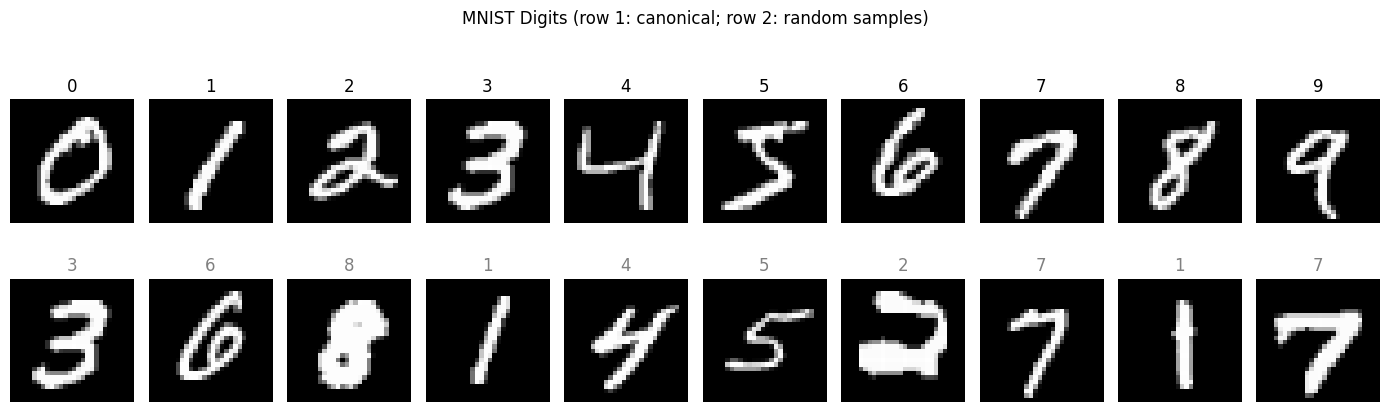

In [13]:
# Load MNIST
# The dataset is already downloaded in ../data/MNIST/
# Normalization values: mean=0.1307, std=0.3081 (computed over the full 60k training set)

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('../data', train=True,  download=True, transform=mnist_transform)
mnist_test  = datasets.MNIST('../data', train=False, download=True, transform=mnist_transform)

mnist_train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True,  num_workers=0) # we'll pick a batch size of 64
mnist_test_loader  = DataLoader(mnist_test,  batch_size=64, shuffle=False, num_workers=0)

print(f"Training samples: {len(mnist_train):,}")
print(f"Test samples:     {len(mnist_test):,}")
print(f"Image shape:      {mnist_train[0][0].shape}  (C, H, W)")
print(f"Classes:          {mnist_train.classes}")

# Visualize some sample digits
fig, axes = plt.subplots(2, 10, figsize=(14, 4.5))
seen = {}
idx = 0
i = 0
while len(seen) < 10:
    img, label = mnist_train[i]
    if label not in seen:
        seen[label] = (img, i)
    i += 1

for col in range(10):
    img, _ = seen[col]
    axes[0, col].imshow(img[0], cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title(f'{col}', fontsize=12)

# Second row: show several random samples
for col in range(10):
    img, label = mnist_train[col * 600 + 7]
    axes[1, col].imshow(img[0], cmap='gray')
    axes[1, col].axis('off')
    axes[1, col].set_title(f'{label}', fontsize=12, color='gray')

plt.suptitle('MNIST Digits (row 1: canonical; row 2: random samples)', y=1.0)
plt.tight_layout()
plt.show()

## Building a CNN for MNIST

Based on our dimension analysis earlier, here's the architecture we'll train:

```text
Input: (1, 28, 28)
 └─ Conv2d(1→32, 3×3, pad=1) + ReLU    → (32, 28, 28)
 └─ MaxPool2d(2×2)                     → (32, 14, 14)
 └─ Conv2d(32→64, 3×3, pad=1) + ReLU   → (64, 14, 14)
 └─ MaxPool2d(2×2)                     → (64, 7, 7)
 └─ Flatten()                          → 3,136
 └─ Linear(3136→128) + ReLU + Dropout  → 128
 └─ Linear(128→10)                     → 10 logits
```

This is a deep learning classic — a descendant of **LeNet-5**, the original CNN published by Yann LeCun in 1998. Ok, let's build it!

In [14]:
class MNISTNet(nn.Module):
    """
    A two-block CNN for MNIST digit recognition.
    Architecture: Conv→ReLU→Pool, Conv→ReLU→Pool, Flatten→FC→Dropout→FC
    """
    
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1: (1,28,28) → (32,14,14)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),    # → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # → (32,14,14)
            # Block 2: (32,14,14) → (64,7,7)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # → (64,7,7)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),                                  # 64 × 7 × 7 = 3,136
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Dropout(0.5),      # Dropout only active in training mode
            nn.Linear(128, 10)    # 10 digit classes
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Verify
mnist_model = MNISTNet()
x_test = torch.randn(4, 1, 28, 28)
print(f"Input shape:  {tuple(x_test.shape)}")
print(f"Output shape: {tuple(mnist_model(x_test).shape)}")
print(f"\nTotal parameters: {sum(p.numel() for p in mnist_model.parameters()):,}")
print()
print(mnist_model)

Input shape:  (4, 1, 28, 28)
Output shape: (4, 10)

Total parameters: 421,642

MNISTNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


Looks good, now we'll turn to training.

## Training the MNIST Model

For MNIST, we use:
- **`nn.CrossEntropyLoss`**: the standard loss for multi-class classification. It combines `log_softmax` and `NLLLoss` in one step — you pass raw logits directly, no softmax needed beforehand.
- **Adam optimizer** with default lr=0.001
- **10 epochs** — enough to reach >99% accuracy on MNIST

Remember: `CrossEntropyLoss` expects **class indices** as targets (integers 0–9), not one-hot vectors.


First, lets look at our training code to ensure we understand what it's doing:

In [15]:
def train_classifier(model, train_loader, test_loader, device, 
                     num_epochs=10, lr=0.001):
    """
    Standard training loop for image classification.
    Returns training loss history and test accuracy history.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    test_accuracies = []
    
    for epoch in range(num_epochs):
        # --- Training phase ---
        model.train()   # Enable dropout etc.
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)              # Forward pass
            loss = criterion(logits, labels)    # CrossEntropy wants raw logits
            loss.backward()                     # Backprop
            optimizer.step()                    # Update weights
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # --- Evaluation phase ---
        model.eval()    # Disable dropout etc.
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                _, predicted = torch.max(logits, dim=1)  # Get class with highest logit; tuple output gives (value_of_max, index_of_max)
                total += labels.size(0) # Add the batch size to total
                correct += (predicted == labels).sum().item() # Add the number of correct predictions in this batch to correct
        acc = 100.0 * correct / total # get the accuracy as a percentage
        test_accuracies.append(acc)
        print(f"Epoch {epoch+1:>2}/{num_epochs}  Loss: {avg_train_loss:.4f}  "
              f"Test Acc: {acc:.2f}%")
    
    return train_losses, test_accuracies


Now let's apply that code to train our CNN on MNIST. This might take a couple of minutes to run (on a CUDA device; even longer on a CPU). If you don't have a GPU, you can run this later (or copy this code to google colab and run it there on a GPU/TPU).

In [16]:
# Train the model (≈3 minutes on a GPU; ≈5 minutes on CPU)
mnist_model = MNISTNet()
print(f"Training MNISTNet on {device}...\n")
train_losses, test_accs = train_classifier(
    mnist_model, mnist_train_loader, mnist_test_loader,
    device=device, num_epochs=10
)

Training MNISTNet on cpu...

Epoch  1/10  Loss: 0.1968  Test Acc: 98.52%
Epoch  2/10  Loss: 0.0740  Test Acc: 98.91%
Epoch  3/10  Loss: 0.0553  Test Acc: 99.13%
Epoch  4/10  Loss: 0.0441  Test Acc: 99.14%
Epoch  5/10  Loss: 0.0387  Test Acc: 99.28%
Epoch  6/10  Loss: 0.0325  Test Acc: 99.26%
Epoch  7/10  Loss: 0.0292  Test Acc: 99.11%
Epoch  8/10  Loss: 0.0256  Test Acc: 99.34%
Epoch  9/10  Loss: 0.0215  Test Acc: 99.34%
Epoch 10/10  Loss: 0.0203  Test Acc: 99.23%


Cool, our model trained and acheive good test accuracy! Let's visualize it

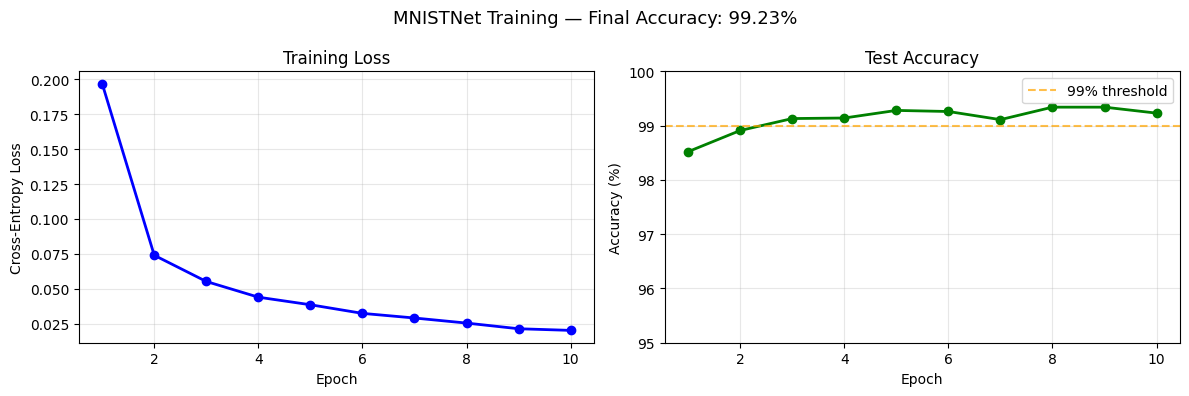


Final test accuracy: 99.23%
Best test accuracy:  99.34%


In [17]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 11), train_losses, 'b-o', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 11), test_accs, 'g-o', linewidth=2)
axes[1].axhline(y=99.0, color='orange', linestyle='--', alpha=0.7, label='99% threshold')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([95, 100])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'MNISTNet Training — Final Accuracy: {test_accs[-1]:.2f}%', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {test_accs[-1]:.2f}%")
print(f"Best test accuracy:  {max(test_accs):.2f}%")

## What Did the CNN Learn?

One of the most insightful things we can do with a trained CNN is **visualize its learned filters**. The first convolutional layer's filters tell us what low-level patterns the network uses as building blocks.

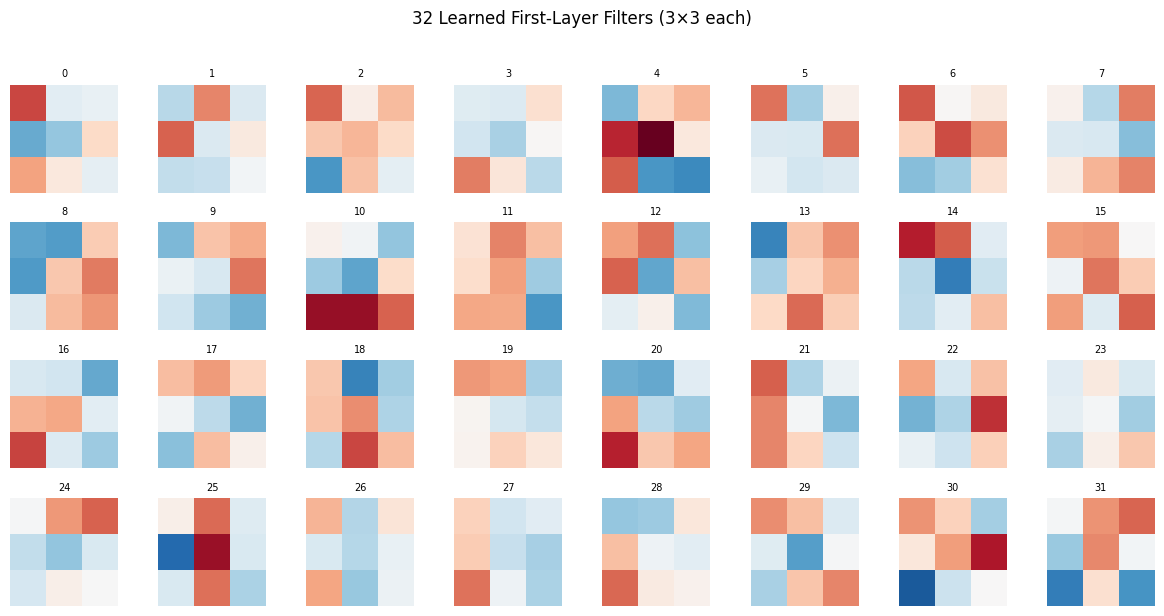

Red = positive weight, Blue = negative weight
Each filter detects a different low-level pattern (edges, corners, textures)


In [18]:
# Visualize the 32 learned first-layer filters
filters = mnist_model.features[0].weight.data.cpu()  # (32, 1, 3, 3)
# Normalize to [-1, 1] for visualization
vmax = filters.abs().max().item()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    f = filters[i, 0]   # Single-channel filter: (3, 3)
    ax.imshow(f, cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.axis('off')
    ax.set_title(str(i), fontsize=7)
plt.suptitle('32 Learned First-Layer Filters (3×3 each)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("Red = positive weight, Blue = negative weight")
print("Each filter detects a different low-level pattern (edges, corners, textures)")

You can imagine trying to <font color="blue">**build** a digit by combining the above filters</font>.

Let's look at at our prediction for the test set and visualize the images that the model got correct and wrong.  We'll need to find a batch with at least some errors (since errors are kind of rare at >99% accuracy).

In [19]:
mnist_model = mnist_model.to(device)

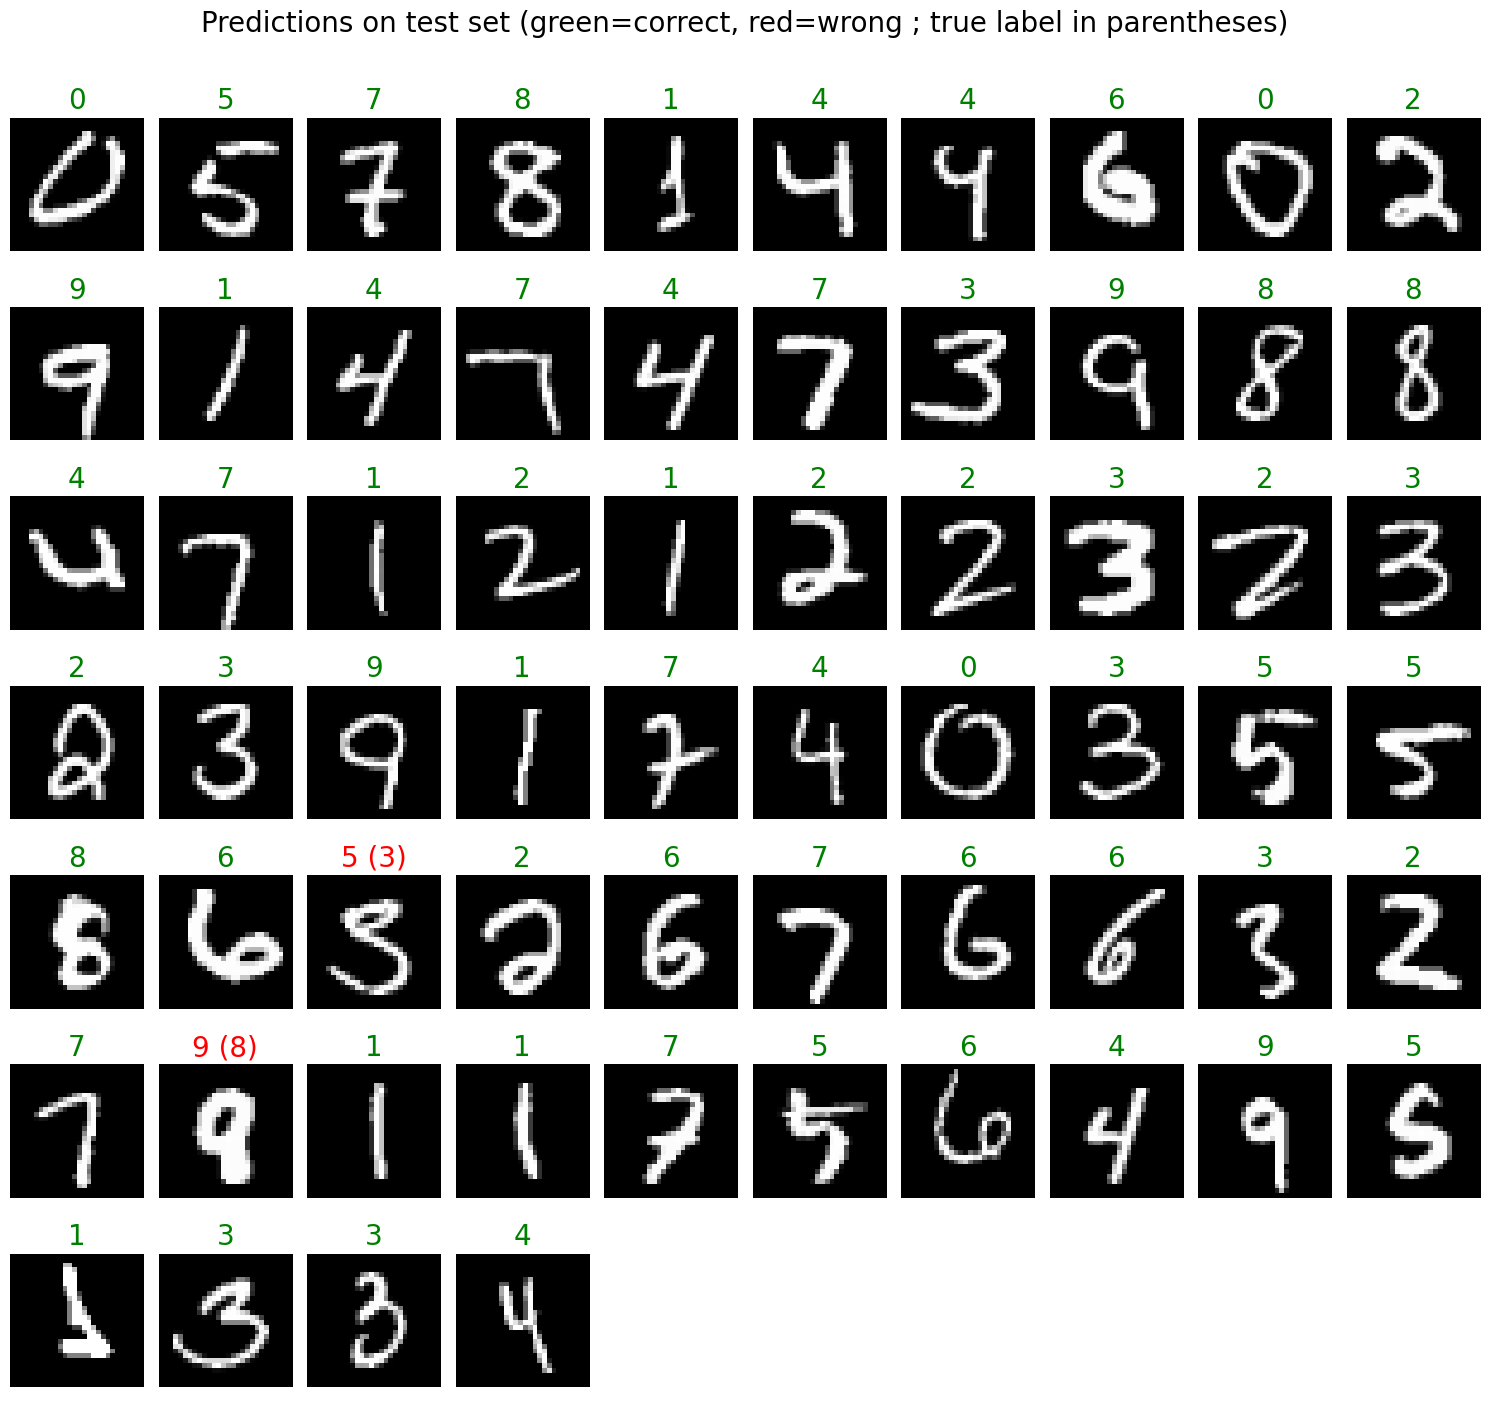

Correct: 62/64 (96.9%) in this batch


In [20]:
# Visualize predictions: green title = correct, red = wrong
mnist_model.eval()

# Get a batch of images and labels with some errors
for images, labels in mnist_test_loader:
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        logits = mnist_model(images)
        _, predicted = torch.max(logits, dim=1)
        if (predicted != labels).sum()>=2:
            break  # Stop at the first batch that has at least one wrong prediction

images, labels = images.cpu(), labels.cpu()  # Move to CPU for visualization
logits = logits.cpu()
predicted = predicted.cpu()

fig, axes = plt.subplots(7, 10, figsize=(15, 14))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i, 0], cmap='gray')
        ax.axis('off')
        true_lbl  = labels[i].item()
        pred_lbl  = predicted[i].item()
        color = 'green' if true_lbl == pred_lbl else 'red'
        label_txt = str(pred_lbl) if true_lbl == pred_lbl else f'{pred_lbl} ({true_lbl})'
        ax.set_title(label_txt, color=color, fontsize=20)
        # Hide subplot if blank
    else:
        ax.axis('off')

plt.suptitle('Predictions on test set (green=correct, red=wrong ; true label in parentheses)', y=1.01, fontsize=20)
plt.tight_layout()
plt.show()

n_correct = (predicted == labels[:len(images)]).sum().item()
print(f"Correct: {n_correct}/{len(images)} ({100*n_correct/len(images):.1f}%) in this batch")

Now that you've seen this on MNIST, you can do the same thing with FASHION_MNIST, which is a more challenging dataset of clothing images.

<!-- Start Exercise 12.2 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 12.2: Modify the CNN Architecture </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

**Fashion-MNIST** is a drop-in replacement for MNIST with the same dimensions (28×28 grayscale, 10 classes) but significantly harder content: T-shirts, trousers, pullovers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots.

Your task is to make `FashionNet`, a modified version of `MNISTNet`, to improve its accuracy by adding an additional convolutional block.

**Steps:**
1. Run the code to load Fashion-MNIST using `datasets.FashionMNIST` and visualize some samples
2. Create `FashionNet` — start with `MNISTNet`'s architecture and add a **third convolutional block**: `Conv2d(64→128, 3×3, padding=1)` + ReLU, before the final MaxPool. You'll need to recalculate the flatten size.
3. Print the model and verify shapes with a dummy input
4. Train for 10 epochs and compare the accuracy to the base `MNISTNet` architecture

**Think about**: Why is Fashion-MNIST harder than regular MNIST? Why might adding a third convolutional block help?

</div>

Here's all the prerequisite code to run first:

In [21]:
# Exercise 12.2: FashionNet — modify MNISTNet for Fashion-MNIST

# Step 1: Run the below code to load Fashion-MNIST
# Imports and train_classifier() repeated here for convenience
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt


def train_classifier(model, train_loader, test_loader, device, 
                     num_epochs=10, lr=0.001):
    """
    Standard training loop for image classification.
    Returns training loss history and test accuracy history.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    test_accuracies = []
    
    for epoch in range(num_epochs):
        # --- Training phase ---
        model.train()   # Enable dropout etc.
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)              # Forward pass
            loss = criterion(logits, labels)    # CrossEntropy wants raw logits
            loss.backward()                     # Backprop
            optimizer.step()                    # Update weights
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # --- Evaluation phase ---
        model.eval()    # Disable dropout etc.
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                _, predicted = torch.max(logits, dim=1)  # Get class with highest logit; tuple output gives (value_of_max, index_of_max)
                total += labels.size(0) # Add the batch size to total
                correct += (predicted == labels).sum().item() # Add the number of correct predictions in this batch to correct
        acc = 100.0 * correct / total # get the accuracy as a percentage
        test_accuracies.append(acc)
        print(f"Epoch {epoch+1:>2}/{num_epochs}  Loss: {avg_train_loss:.4f}  "
              f"Test Acc: {acc:.2f}%")
    
    return train_losses, test_accuracies


# Load and transform Fashion-MNIST
#   (FashionMNIST mean=0.2860, std=0.3530)
fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])
fashion_train = datasets.FashionMNIST('../data', train=True,  download=True, transform=fashion_transform)
fashion_test  = datasets.FashionMNIST('../data', train=False, download=True, transform=fashion_transform)
fashion_train_loader = DataLoader(fashion_train, batch_size=64, shuffle=True)
fashion_test_loader  = DataLoader(fashion_test,  batch_size=64, shuffle=False)

Just so you can see the Fashion-MNIST dataset, let's visualize some samples:

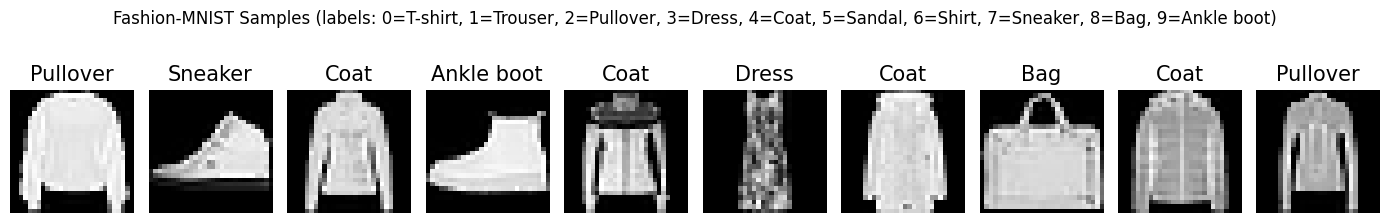

In [22]:
# Step 1 (continued): Visualize some example images and labels from Fashion-MNIST
labels = fashion_train.classes
fig, axes = plt.subplots(1, 10, figsize=(14, 2.5))
for col in range(10):
    img, label = fashion_train[col * 600 + 7]  # Just pick some random samples
    axes[col].imshow(img[0], cmap='gray')
    axes[col].axis('off')
    axes[col].set_title(f'{labels[label]}', fontsize=15)

plt.suptitle('Fashion-MNIST Samples (labels: 0=T-shirt, 1=Trouser, 2=Pullover, 3=Dress, 4=Coat, 5=Sandal, 6=Shirt, 7=Sneaker, 8=Bag, 9=Ankle boot)', y=1.0)
plt.tight_layout()
plt.show()

And here's the part for you to do:

FashionNet(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Input shape:  (4, 1, 28, 28)
Output shape: (4, 10)

Total parameters: 1,701,130

Training FashionNet on cpu...

Epoch  1/10  Loss: 0.4719  Test Acc: 88.70%
Epoch  2/10  Loss: 0.2927  Test Acc: 90.44%
Epoch  3/10  Loss: 0.2469  Test Acc: 90.52%
Epoch  4/10  Loss

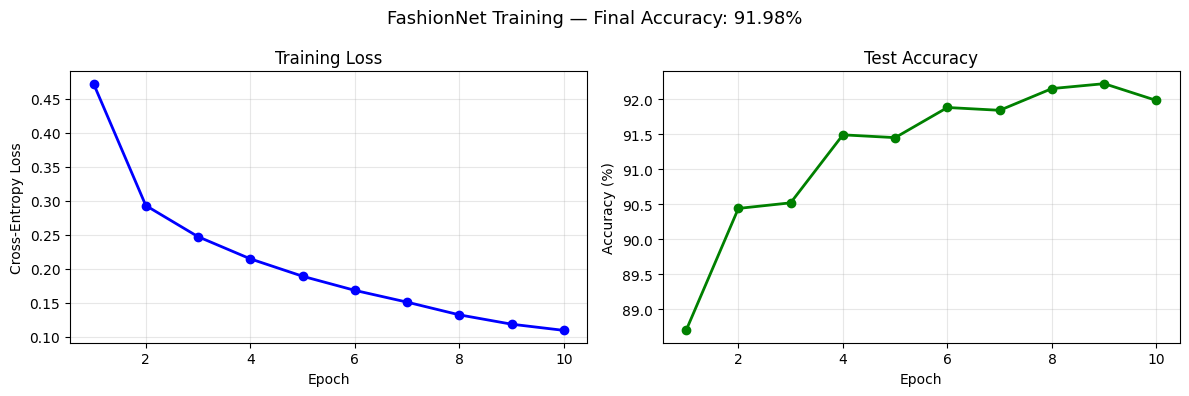


Final test accuracy: 91.98%
Best test accuracy:  92.22%


In [23]:
# Step 2: Define FashionNet with an extra convolutional block
# Architecture hint:
#   Block 1: Conv(1→32, 3x3, pad=1) + ReLU + MaxPool → (32, 14, 14)
#   Block 2: Conv(32→64, 3x3, pad=1) + ReLU + MaxPool → (64, 7, 7)
#   Block 3: Conv(64→128, 3x3, pad=1) + ReLU          → (128, 7, 7) 
#            (no MaxPool here — image is already small)
#   Classifier: Flatten → Linear(? → 256) + ReLU + Dropout → Linear(256 → 10)
#
# Hint: What is the flatten size after Block 3? 128 × 7 × 7 = 6,272

class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: (1,28,28) → (32,14,14)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),    # → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # → (32,14,14)
            # Block 2: (32,14,14) → (64,7,7)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # → (64,7,7)
            # Block 3: (64,7,7) → (128,7,7) — no MaxPool, image is already small
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # → (128,7,7)
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                  # 128 × 7 × 7 = 6,272
            nn.Linear(6272, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)                             # 10 Fashion-MNIST classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Step 3: Verify shapes
model = FashionNet()
print(model)
x_dummy = torch.randn(4, 1, 28, 28)
print(f"\nInput shape:  {tuple(x_dummy.shape)}")
print(f"Output shape: {tuple(model(x_dummy).shape)}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


# Step 4: Train and evaluate
print(f"\nTraining FashionNet on {device}...\n")
fashion_losses, fashion_accs = train_classifier(
    model, fashion_train_loader, fashion_test_loader,
    device=device, num_epochs=10
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 11), fashion_losses, 'b-o', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 11), fashion_accs, 'g-o', linewidth=2)
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'FashionNet Training — Final Accuracy: {fashion_accs[-1]:.2f}%', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {fashion_accs[-1]:.2f}%")
print(f"Best test accuracy:  {max(fashion_accs):.2f}%")


**Q**: Why is Fashion-MNIST harder than MNIST? Why might adding the third convolutional block improve accuracy?

Why Fashion-MNIST is harder: The classes are way more visually similar: a T-shirt, shirt, and pullover all look like upper-body clothing with the same 28×28 grayscale format. Digits (0–9) have very distinct shapes, so even a shallow network can tell them apart easily. Fashion items share textures, outlines, and structure in ways digits just don't.

Why the third conv block helps: The extra block (64→128 channels) lets the network learn more abstract, high-level features before flattening. With only 2 blocks you're limited in what patterns you can detect, adding that third layer gives the model more capacity to distinguish subtle differences between, say, a coat vs. a dress without needing a bigger image.

<hr/>
<!-- End Exercise 12.2 -->

# 12.4 CIFAR-10 and More Complex CNNs

<img alt="The advanced terminator" src="../images/L12_terminator_advanced.gif" width="800" style="display:block;">
<font size=2>Terminator vision gets an upgrade in <i>Terminator Genisys (2015)</i>, but the movie gets a major downgrade. Yuck.</font>

MNIST is essentially a solved problem — the images are tiny, clean, and centered. **CIFAR-10** is a much harder benchmark:

| Feature | MNIST | CIFAR-10 |
|---------|-------|----------|
| Image size | 28×28 | 32×32 |
| Channels | 1 (grayscale) | 3 (RGB) |
| Classes | 10 digits | 10 objects |
| Typical CNN accuracy | >99% | 70–93%+ |
| Challenge level | Easy | Hard |

The CIFAR-10 classes are: **airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck**.

The difficulty comes from:
- Natural image variation (different angles, lighting, backgrounds)
- Color as a meaningful feature
- Visually similar classes (cat vs. dog, automobile vs. truck)
- Limited image resolution (32×32 is very small)

100.0%
/Users/carlocastro/Documents/bus675_git/.venv312/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 50,000
Test samples:     10,000
Image shape:      torch.Size([3, 32, 32])  (C, H, W)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


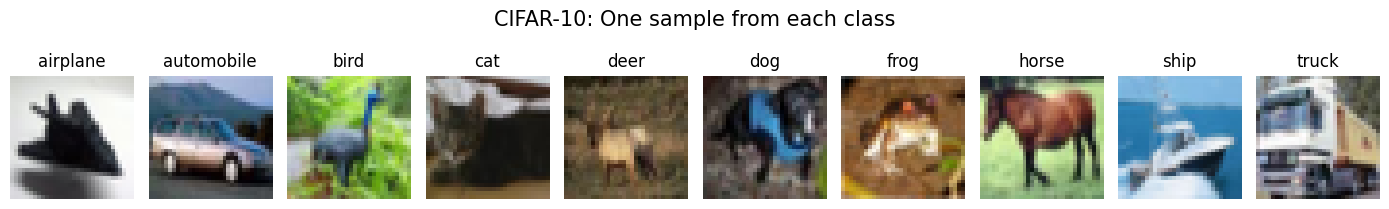

In [24]:
# Load CIFAR-10
# CIFAR-10 mean and std computed from the training set
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])
# download=True will download if not already present
cifar_train = datasets.CIFAR10('../data/CIFAR10', train=True,  download=True, transform=basic_transform)
cifar_test  = datasets.CIFAR10('../data/CIFAR10', train=False, download=True, transform=basic_transform)
cifar_train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True,  num_workers=0)
cifar_test_loader  = DataLoader(cifar_test,  batch_size=128, shuffle=False, num_workers=0)

CIFAR_CLASSES = cifar_train.classes

print(f"Training samples: {len(cifar_train):,}")
print(f"Test samples:     {len(cifar_test):,}")
print(f"Image shape:      {cifar_train[0][0].shape}  (C, H, W)")
print(f"Classes: {CIFAR_CLASSES}")

# Visualize one sample from each class
# (We need to work with the raw un-normalized images for visualization)
raw_train = datasets.CIFAR10('../data/CIFAR10', train=True, download=False, 
                              transform=transforms.ToTensor())

# Find one example of each class
class_examples = {}
for img, label in raw_train:
    if label not in class_examples:
        class_examples[label] = img
    if len(class_examples) == 10:
        break

fig, axes = plt.subplots(1, 10, figsize=(14, 2.0))
for c in range(10):
    img = class_examples[c].permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    axes[c].imshow(img)
    axes[c].axis('off')
    axes[c].set_title(CIFAR_CLASSES[c], fontsize=12)

plt.suptitle('CIFAR-10: One sample from each class', y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

## Building a Deeper CNN for CIFAR-10

The extra complexity of CIFAR-10 demands a deeper, more capable architecture. We'll add two important components:

**`nn.BatchNorm2d`**: Normalizes the activations within each mini-batch. This:
- Stabilizes training and allows higher learning rates
- Acts as a mild regularizer
- Placed **after** Conv2d and **before** ReLU

**`nn.Dropout2d`**: Drops entire feature map channels during training (as opposed to individual neurons). Helps prevent over-reliance on specific feature maps.

Our architecture uses **three convolutional blocks**, with the number of filters doubling at each stage (32 → 64 → 128):

In [25]:
class CIFAR10Net(nn.Module):
    """
    A three-block CNN for CIFAR-10 classification.
    Input: (batch, 3, 32, 32) — color images
    
    Architecture:
      Block 1: Conv→BN→ReLU→Conv→BN→ReLU→MaxPool→Dropout2d  (3→32→32, 32→16)
      Block 2: Conv→BN→ReLU→Conv→BN→ReLU→MaxPool→Dropout2d  (32→64, 16→8)
      Block 3: Conv→BN→ReLU→MaxPool→Dropout2d                (64→128, 8→4)
      Classifier: Flatten→Linear→ReLU→Dropout→Linear         (2048→512→10)
    """
    
    def __init__(self):
        super().__init__()
        
        # Block 1: 32×32 → 16×16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),    # (3,32,32) → (32,32,32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),   # (32,32,32) → (32,32,32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                # (32,32,32) → (32,16,16)
            nn.Dropout2d(0.25)
        )
        
        # Block 2: 16×16 → 8×8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),   # (32,16,16) → (64,16,16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),   # (64,16,16) → (64,16,16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                # (64,16,16) → (64,8,8)
            nn.Dropout2d(0.25)
        )
        
        # Block 3: 8×8 → 4×4
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),  # (64,8,8) → (128,8,8)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                # (128,8,8) → (128,4,4)
            nn.Dropout2d(0.25)
        )
        
        # Classifier: 128×4×4 = 2048 → 10 classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


Let's see how the CIFAR-10 image data changes shape as it passes through this architecture:

In [26]:
# Verify shapes
cifar_model = CIFAR10Net()
x_cifar = torch.randn(4, 3, 32, 32)  # Simulate a batch of 4 CIFAR-10 images
print(f"Input:  {tuple(x_cifar.shape)}  (batch of 4 RGB images of size 32x32)")
print(f"Output: {tuple(cifar_model(x_cifar).shape)}  (batch of 4 logits (scores) across 10 classes)")
print(f"\nTotal parameters: {sum(p.numel() for p in cifar_model.parameters()):,}")

# Trace shapes through each block
x = x_cifar
for i, block in enumerate([cifar_model.block1, cifar_model.block2, 
                            cifar_model.block3, cifar_model.classifier], 1):
    x = block(x)
    label = f"Block {i}" if i < 4 else "Classifier"
    print(f"  After {label}: {tuple(x.shape)}")

Input:  (4, 3, 32, 32)  (batch of 4 RGB images of size 32x32)
Output: (4, 10)  (batch of 4 logits (scores) across 10 classes)

Total parameters: 1,194,282
  After Block 1: (4, 32, 16, 16)
  After Block 2: (4, 64, 8, 8)
  After Block 3: (4, 128, 4, 4)
  After Classifier: (4, 10)


## Training on CIFAR-10

CIFAR-10 is significantly more demanding to train than MNIST:
- Larger images (3 channels × 32×32 vs 1 × 28×28)
- Harder classes with more visual variation
- Needs more epochs to converge (typically 50–200)

We'll use a **cosine annealing** learning rate schedule, which gradually reduces the learning rate over training and often improves final accuracy. We'll train for 20 epochs to demonstrate the learning trajectory — production models train for much longer.

In [27]:
def train_cifar(model, train_loader, test_loader, device, num_epochs=20, lr=0.001):
    """Training loop with cosine LR annealing for CIFAR-10."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    test_accs    = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                _, pred = torch.max(model(images), 1)
                total   += labels.size(0)
                correct += (pred == labels).sum().item()
        acc = 100.0 * correct / total
        test_accs.append(acc)
        print(f"Epoch {epoch+1:>2}/{num_epochs}  Loss: {avg_loss:.4f}  Acc: {acc:.1f}%  "
              f"LR: {scheduler.get_last_lr()[0]:.5f}")
    
    return train_losses, test_accs


# Train! (Warning: this takes several minutes on CPU. GPU recommended.)
# On a typical laptop CPU: ~not sure, could be ~1hr (3-5 min/epoch)
# On GPU: ~6 minutes (15-30 sec/epoch)
print(f"Training CIFAR10Net on {device}...")
print("(This will take a while — feel free to run and come back)\n")

cifar_model = CIFAR10Net()
cifar_losses, cifar_accs = train_cifar(
    cifar_model, cifar_train_loader, cifar_test_loader,
    device=device, num_epochs=20
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(cifar_losses)+1), cifar_losses, 'b-o', linewidth=2)
axes[0].set_title('Training Loss (CIFAR-10)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cifar_accs)+1), cifar_accs, 'g-o', linewidth=2)
axes[1].set_title('Test Accuracy (CIFAR-10)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'CIFAR10Net — Final Accuracy: {cifar_accs[-1]:.1f}% (20 epochs)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {cifar_accs[-1]:.1f}%")
print("Training longer (100+ epochs) and with augmentation can push this above 85%.")

Training CIFAR10Net on cpu...
(This will take a while — feel free to run and come back)

Epoch  1/20  Loss: 1.6285  Acc: 54.8%  LR: 0.00099
Epoch  2/20  Loss: 1.2713  Acc: 63.6%  LR: 0.00098
Epoch  3/20  Loss: 1.1291  Acc: 67.1%  LR: 0.00095
Epoch  4/20  Loss: 1.0318  Acc: 70.3%  LR: 0.00090
Epoch  5/20  Loss: 0.9684  Acc: 71.9%  LR: 0.00085
Epoch  6/20  Loss: 0.9057  Acc: 74.3%  LR: 0.00079


KeyboardInterrupt: 

## Data Augmentation

**Data augmentation** applies random transformations to training images during loading. The key insight is that many transformations **preserve the label** — a flipped dog is still a dog, a randomly cropped airplane is still an airplane — but they look sufficiently different that the model can't simply memorize them.

Common augmentations for CIFAR-10:

| Transform | Effect | Why it helps |
|-----------|--------|-------------|
| `RandomHorizontalFlip()` | Mirror image 50% of the time | Animals/vehicles look valid either way |
| `RandomCrop(32, padding=4)` | Shift image by up to 4 pixels | Builds position invariance |
| `ColorJitter(...)` | Random brightness/contrast/saturation | Handles different lighting conditions |
| `RandomRotation(...)` | Rotate by small angle | Objects at slight angles are the same |

Augmentation is applied **only to the training set** — never to the test set. The test set is always evaluated with the same basic transform.

In [ ]:
# Visualize augmentation effects on a single image

# Get a raw image (un-normalized) for visualization
raw_img, raw_label = raw_train[0]   # First CIFAR-10 train image
raw_pil = torchvision.transforms.ToPILImage()(raw_img)  # Convert to PIL for augmentation

# Find the mean color value for CIFAR-10. We'll use this to fill empty pixels from augmentations like rotation or cropping
fill = tuple(int(255 * m) for m in CIFAR_MEAN)  # (125, 123, 113)

augmentation_transforms = {
    'Original': transforms.Compose([transforms.ToTensor()]),
    'HFlip': transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()]),
    'Crop': transforms.Compose([transforms.RandomCrop(32, padding=4, fill=fill), transforms.ToTensor()]),
    'ColorJitter': transforms.Compose([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
        transforms.ToTensor()
    ]),
    'Rotation': transforms.Compose([transforms.RandomRotation(15, fill=fill), transforms.ToTensor()]),
    'All Combined': transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4, fill=fill),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomRotation(15, fill=fill),
        transforms.ToTensor()
    ])
}

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, (name, tfm) in zip(axes, augmentation_transforms.items()):
    augmented = tfm(raw_pil).permute(1, 2, 0).numpy()
    augmented = np.clip(augmented, 0, 1)
    ax.imshow(augmented)
    ax.axis('off')
    ax.set_title(name, fontsize=9)

plt.suptitle(f'Augmentations on: {CIFAR_CLASSES[raw_label]} — label never changes!', 
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

To be honest, this isn't the best way to do data augmentation, particularly for rotation and color jitter. In practice, you would want to use a more powerful library like `albumentations` which provides more advanced augmentation techniques (techniques to intelligently fill the empty areas created by rotation and translation, etc.). But for now, this is sufficient to demonstrate the concept.

In [ ]:
# Augmented training set and data loader
# Note: only the training transform changes — the test transform stays the same!

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4, fill=fill),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15, fill=fill),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)   # Same normalization as before
])

cifar_train_aug = datasets.CIFAR10('../data/CIFAR10', train=True, download=False, 
                                    transform=augmented_transform)
cifar_aug_loader = DataLoader(cifar_train_aug, batch_size=128, shuffle=True, num_workers=0)

# Train a new model with augmentation
# Using the same architecture for a fair comparison
print("Training CIFAR10Net WITH data augmentation...")
print("(Same architecture, same epochs — augmentation is the only change)\n")

cifar_model_aug = CIFAR10Net()
torch.manual_seed(42)   # Reset seed for reproducibility
cifar_aug_losses, cifar_aug_accs = train_cifar(
    cifar_model_aug, cifar_aug_loader, cifar_test_loader,
    device=device, num_epochs=20
)

# Compare: with or without augmentation
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cifar_accs,     'b-o', linewidth=2, label='No augmentation')
plt.plot(range(1, 21), cifar_aug_accs, 'g-s', linewidth=2, label='With augmentation')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('CIFAR-10: Impact of Data Augmentation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal accuracy WITHOUT augmentation: {cifar_accs[-1]:.1f}%")
print(f"Final accuracy WITH augmentation:    {cifar_aug_accs[-1]:.1f}%")
print("\nNote: Augmentation benefits become more pronounced with longer training.")
print("At 100+ epochs, the gap often reaches 5–10 percentage points.")

<!-- Start Exercise 12.3 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 12.3: Design a Data Augmentation Pipeline </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Design an augmentation pipeline for CIFAR-10 using the `albumentations` library that goes **beyond the basic transforms** used in the lecture. Your pipeline must include at least **four distinct transforms** and show the effect visually.

Note: You may need to run `pip install augmentations opencv-python` to get the libraries needed.

**Steps:**
1. Explore the [albumentations docs](https://albumentations.ai/docs/) to find at least two transforms **not used in the lecture** (e.g., `GaussianBlur`, `CoarseDropout`, `GridDistortion`, `CLAHE`, `Perspective`)
2. Build `my_augmentation` as an `A.Compose([...])` pipeline with your chosen transforms. Leave out `A.Normalize` and `ToTensorV2` here (we would add those only when integrating with a training loop, but here we just want to see the effect of the augmentations themselves)
3. Visualize the pipeline: show an original image alongside **8 random augmented versions** of it

**Note on the albumentations API**: Unlike `torchvision.transforms`, albumentations pipelines operate on **numpy arrays** and are called as `result = pipeline(image=np_array)`. The augmented image is in `result['image']`.

**Think about**: Are all augmentations appropriate for all datasets? (Consider: is `VerticalFlip` useful for CIFAR-10 objects? What about for satellite imagery?)

</div>

In [ ]:
# Exercise 12.3: Design a custom augmentation pipeline using albumentations

import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import albumentations as A
import cv2  # albumentations uses OpenCV for some operations

# Load one raw CIFAR-10 image for visualization
raw_dataset = datasets.CIFAR10('../data/CIFAR10', train=True, download=False,
                                transform=transforms.ToTensor())

sample_img, sample_label = raw_dataset[42] # Update this if you want to see some other images
sample_pil = torchvision.transforms.ToPILImage()(sample_img)
sample_np  = np.array(sample_pil)   # albumentations expects numpy: (H, W, C), uint8

CIFAR_CLASSES = raw_dataset.classes

# Step 1: Define your albumentations pipeline
# Include at least 4 transforms, 2+ should be new (not used in the lecture)
# albumentations docs: https://albumentations.ai/docs/
#
# Note: leave out A.Normalize() and ToTensorV2() here — normalized pixel values
# won't display correctly as images. Add them at the end when training.
my_augmentation = A.Compose([
    # From the lecture (but albumentations version):
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),

    # NEW — not used in lecture:
    # GaussianBlur: slightly blurs the image, simulates out-of-focus or motion blur
    A.GaussianBlur(blur_limit=(3, 5), p=0.4),

    # CoarseDropout: randomly blacks out small rectangular patches (simulates occlusion)
    A.CoarseDropout(max_holes=8, max_height=4, max_width=4, fill_value=0, p=0.5),

    # Perspective: applies a slight perspective warp — like viewing the object at an angle
    A.Perspective(scale=(0.05, 0.1), p=0.4),
])


# Step 2: Visualize — original + 8 augmented versions
# albumentations pipelines are called as: result = pipeline(image=np_array)
# the augmented image is in result['image'] as a (H, W, C) numpy array
fig, axes = plt.subplots(1, 9, figsize=(16, 3))

axes[0].imshow(sample_pil)
axes[0].axis('off')
axes[0].set_title('Original', fontweight='bold', fontsize=20)

for i in range(1, 9):
    aug_img = my_augmentation(image=sample_np)['image']   # (H, W, C) numpy array
    axes[i].imshow(aug_img)
    axes[i].axis('off')
    axes[i].set_title(f'Aug {i}', fontsize=20)

plt.suptitle(f'My augmentation pipeline on: {CIFAR_CLASSES[sample_label]}', y=1.02, fontsize=20)
plt.tight_layout()
plt.show()


<hr/>
<!-- End Exercise 12.3 -->

## Summary

This lecture introduced convolutional neural networks from the ground up — from the mechanics of a single kernel sliding across pixels to training a deep network on natural images.

### Key Takeaways

**Convolutional Layers (`nn.Conv2d`)**:
- Kernels slide across the input and compute weighted sums — detecting local patterns at every position
- **Parameter sharing** makes convolutions far more parameter-efficient than fully connected layers
- `in_channels`, `out_channels`, `kernel_size`, `stride`, `padding` control the layer's behavior
- Output size formula: $H_{out} = \lfloor (H_{in} + 2P - K) / S \rfloor + 1$

**Pooling and Architecture**:
- MaxPool2d down-samples spatial dimensions and builds translation invariance
- Standard pattern: `[Conv → ReLU → MaxPool] × N → Flatten → FC layers`
- Spatial dimensions shrink; channel depth grows — a deliberate design choice

**MNIST CNN**:
- Two convolutional blocks are sufficient to exceed 99% accuracy
- `nn.CrossEntropyLoss` is the standard loss for classification; pass raw logits directly
- Always call `model.train()` / `model.eval()` around training / evaluation phases

**CIFAR-10 and Deeper Networks**:
- Natural images demand deeper networks with batch normalization
- `nn.BatchNorm2d` stabilizes training and allows better generalization
- Data augmentation significantly improves generalization at minimal computational cost
- Augmentations must be **label-preserving** and applied only to the training set

### Methods and Architecture beyond CNNs

CNNs are the foundation for computer vision, but the field has advanced significantly beyond them:
- **Transfer learning**: use pre-trained CNNs (ResNet, EfficientNet) as feature extractors — far more practical than training from scratch
- **Transformer architectures** have challenged CNNs even for vision (Vision Transformers / ViT)
- **Object detection and segmentation** extend classification to localizing objects in an image

## Extended Learning Resources

For a deeper, more visual understanding, I highly recommend:

1. **[But What is a Convolution? (3blue1brown)](https://youtu.be/KuXjwB4LzSA)** (23 min) - Build intution for convolutions and what they do
2. **[Convolution and Probability (3blue1brown)](https://youtu.be/IaSGqQa5O-M)** (27 min) - Explains why convolutions are fundamental to probability!
3. **[Feature Visualization (arxiv insights)](https://youtu.be/McgxRxi2Jqo)]** (15 min) - Visualize the features that different layers extract from images.

## Reflection Questions

Think about the following as you reflect on this lecture:

1. **Why CNNs vs MLPs**: An MLP with the same number of parameters as a CNN should theoretically be able to learn the same functions — but in practice CNNs dramatically outperform MLPs on image data. Why do you think this is? What assumptions about image data does the CNN architecture encode?

2. **Parameter sharing**: The same filter is applied at every spatial position in a convolutional layer. What implicit assumption does this make about visual features? When might this assumption break down?

3. **Depth vs width**: We increased model depth (more blocks) to handle CIFAR-10. Could we instead increase width (more filters per layer)? What are the tradeoffs of each approach?

4. **Augmentation design**: You designed a custom augmentation pipeline in Exercise 12.3. How would your choices change if the dataset were medical X-ray images? Satellite imagery? Documents/text?

5. **Practical limits**: Our CIFAR-10 model reaches ~80% accuracy after 20 epochs. State-of-the-art models achieve >99% on CIFAR-10. What factors account for this gap? What would you change first to narrow it?

6. **Business applications**: Where in a business context would image classification be most valuable? Think of a specific scenario and describe what the training data, classes, and success metric would look like.

**Your reflection:**

[Write your thoughts here]